In [41]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [42]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device : {device}")

Using device : cuda


In [43]:
torch.manual_seed(42)

In [44]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


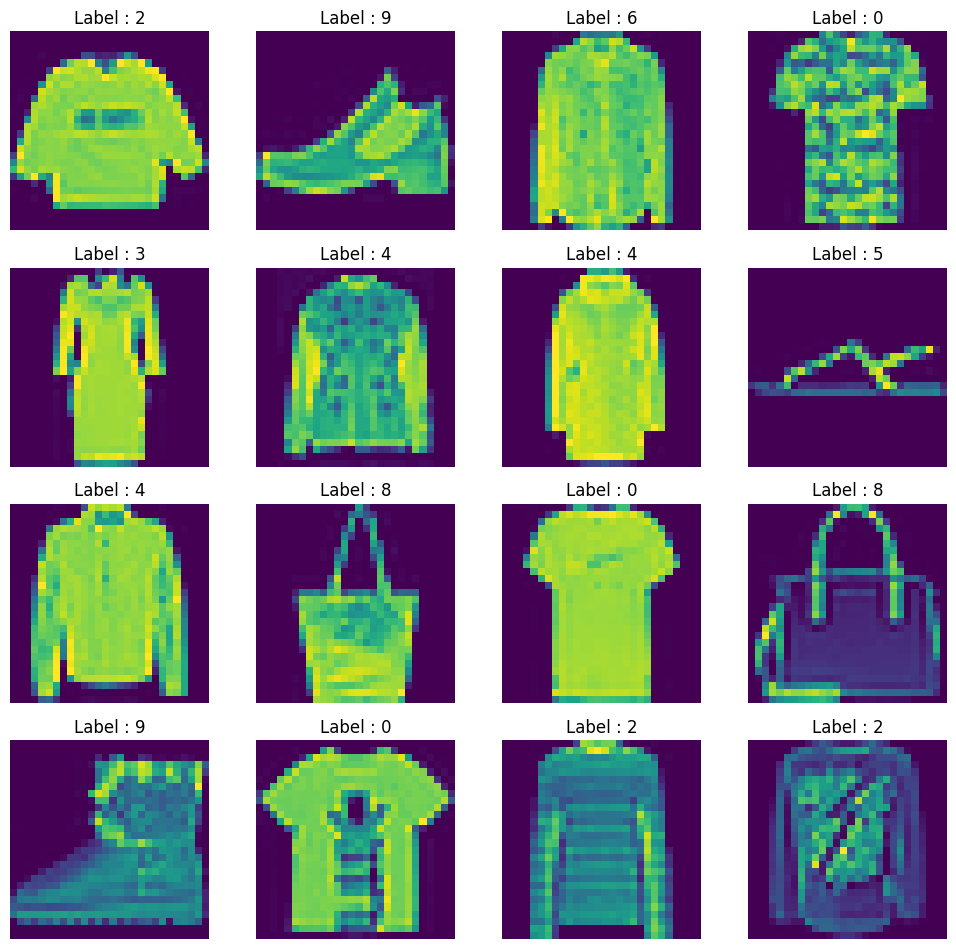

In [45]:
fig,axes = plt.subplots(4,4,figsize = (10,10))

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label : {df.iloc[i,0]}")

plt.tight_layout(rect = [0,0,1,0.96])
plt.show()

In [98]:
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [99]:
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

In [100]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [49]:
# X = df.iloc[:,1:].values
# y = df.iloc[:,0].values

In [50]:
# from sklearn.model_selection import train_test_split
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [51]:
# X_train = X_train/255.0
# X_test = X_test/255.0

In [52]:
# X_train


In [53]:
# # custom dataset class

# class CustomDataset(Dataset):

#   def __init__(self,features,labels):
#     self.features = torch.tensor(features,dtype = torch.float32).reshape(-1,1,28,28)
#     self.labels = torch.tensor(labels,dtype = torch.long)

#   def __len__(self):
#     return len(self.features)

#   def __getitem__(self,idx):
#     return self.features[idx], self.labels[idx]

In [54]:
# train_dataset = CustomDataset(X_train,y_train)

In [55]:
# len(train_dataset)

In [56]:
# train_dataset[0]

In [57]:
# create test dataset
# test_dataset = CustomDataset(X_test,y_test)

In [58]:
# train_loader = DataLoader(train_dataset,batch_size=128,shuffle = True)
# test_loader = DataLoader(test_dataset,batch_size = 128,shuffle = False)

In [101]:
import torch
import torch.nn as nn

class MyModel(nn.Module):

    def __init__(self, input_features):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                input_features,
                64,
                kernel_size=5,
                padding="same"
            ),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(
                kernel_size=5,
                stride=2
            ),

            # Block 2
            nn.Conv2d(
                64,
                64,
                kernel_size=5,
                padding="same"
            ),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(
                kernel_size=5,
                stride=2
            ),

            # Block 3
            nn.Conv2d(
                64,
                64,
                kernel_size=5,
                padding="same"
            ),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Force a fixed spatial size
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            # Output of AdaptiveAvgPool2d:
            # [batch_size, 64, 1, 1]
            # After Flatten:
            # [batch_size, 64]

            nn.Linear(64, 256),

            nn.ReLU(),

            nn.Dropout(p=0.3),

            nn.Linear(256, 10)
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [102]:
epochs = 100
learning_rate = 0.002

In [103]:
# instantiate the model
model = MyModel(
    input_features=1
)

model = model.to(device)

# loss function
criterion = nn.CrossEntropyLoss()

In [104]:
learning_rate = 0.001
weight_decay = 1e-4

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

In [105]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [64]:
# number of batches
# len(train_loader)

In [106]:
def calculate_accuracy(model, data_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for batch_features, batch_labels in data_loader:

            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)

            _, predicted = torch.max(outputs, 1)

            total += batch_labels.size(0)

            correct += (
                predicted == batch_labels
            ).sum().item()

    return 100 * correct / total

In [107]:
batch_features, batch_labels = next(iter(train_loader))

batch_features = batch_features.to(device)

with torch.no_grad():
    feature_output = model.features(batch_features)

print("Feature output shape:", feature_output.shape)

flattened_size = feature_output.view(
    feature_output.size(0), -1
).shape[1]

print("Flattened size:", flattened_size)

Feature output shape: torch.Size([32, 64, 1, 1])
Flattened size: 64


In [67]:
# print(model)

In [108]:
epochs = 100

train_losses = []
train_accuracies = []
test_accuracies = []
learning_rates = []

for epoch in range(epochs):

    # =========================
    # Training
    # =========================

    model.train()

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # Forward pass
        outputs = model(batch_features)

        # Calculate loss
        loss = criterion(
            outputs,
            batch_labels
        )

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_epoch_loss += loss.item()


    # Average loss
    avg_epoch_loss = (
        total_epoch_loss /
        len(train_loader)
    )

    train_losses.append(
        avg_epoch_loss
    )


    # =========================
    # Calculate Accuracy
    # =========================

    train_acc = calculate_accuracy(
        model,
        train_loader
    )

    test_acc = calculate_accuracy(
        model,
        test_loader
    )

    train_accuracies.append(
        train_acc
    )

    test_accuracies.append(
        test_acc
    )


    # =========================
    # Learning Rate Scheduler
    # =========================

    scheduler.step(test_acc)


    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']

    learning_rates.append(
        current_lr
    )


    # =========================
    # Print Results
    # =========================

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {avg_epoch_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

Epoch 1/100 | Loss: 0.5532 | Train Acc: 84.02% | Test Acc: 85.19% | LR: 0.001000
Epoch 2/100 | Loss: 0.4017 | Train Acc: 86.48% | Test Acc: 87.37% | LR: 0.001000
Epoch 3/100 | Loss: 0.3661 | Train Acc: 88.19% | Test Acc: 88.61% | LR: 0.001000
Epoch 4/100 | Loss: 0.3433 | Train Acc: 88.08% | Test Acc: 88.77% | LR: 0.001000
Epoch 5/100 | Loss: 0.3282 | Train Acc: 89.36% | Test Acc: 89.62% | LR: 0.001000
Epoch 6/100 | Loss: 0.3184 | Train Acc: 89.23% | Test Acc: 89.59% | LR: 0.001000
Epoch 7/100 | Loss: 0.3099 | Train Acc: 87.95% | Test Acc: 87.95% | LR: 0.001000
Epoch 8/100 | Loss: 0.3022 | Train Acc: 90.13% | Test Acc: 89.92% | LR: 0.001000
Epoch 9/100 | Loss: 0.2976 | Train Acc: 90.12% | Test Acc: 90.11% | LR: 0.001000
Epoch 10/100 | Loss: 0.2922 | Train Acc: 90.09% | Test Acc: 90.46% | LR: 0.001000
Epoch 11/100 | Loss: 0.2864 | Train Acc: 89.88% | Test Acc: 89.73% | LR: 0.001000
Epoch 12/100 | Loss: 0.2847 | Train Acc: 90.14% | Test Acc: 90.18% | LR: 0.001000
Epoch 13/100 | Loss: 0.28

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, linewidth=2)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.show()

In [ ]:
model.eval()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    linewidth=2,
    marker='o',
    markevery=10
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")

plt.title("Training vs Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "T-shirt",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Boot"
    ]
)

plt.figure(figsize=(10,10))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=[
        "T-shirt",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Boot"
    ]
))

In [ ]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Boot"
]

model.eval()

shown = 0

plt.figure(figsize=(12,8))

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        for i in range(len(images)):

            if preds[i] == labels[i]:

                shown += 1

                plt.subplot(2,5,shown)

                plt.imshow(images[i].cpu().reshape(28,28), cmap='gray')

                plt.title(class_names[preds[i]])

                plt.axis("off")

                if shown == 10:
                    break

        if shown == 10:
            break

plt.suptitle("Correct Predictions")
plt.show()

In [ ]:
model.eval()

shown = 0

plt.figure(figsize=(12,8))

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        for i in range(len(images)):

            if preds[i] != labels[i]:

                shown += 1

                plt.subplot(2,5,shown)

                plt.imshow(images[i].cpu().reshape(28,28), cmap='gray')

                plt.title(
                    f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}",
                    fontsize=9
                )

                plt.axis("off")

                if shown == 10:
                    break

        if shown == 10:
            break

plt.suptitle("Incorrect Predictions")
plt.show()

In [ ]:
torch.save(model.state_dict(), "fashion_mnist_mlp.pth")

In [ ]:
plt.savefig("results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.savefig("results/accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.savefig("results/confusion_matrix.png", dpi=300, bbox_inches="tight")